<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Importing Libraries</b>
</div>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, chi2, SelectKBest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Load and Clean Dataset


In [18]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

# Replace missing values


In [19]:
df = df.replace("?", np.nan)
df = df.dropna()
df = df.astype(float)

# Features and target


In [20]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 2. Feature Importance (Random Forest)


In [21]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance


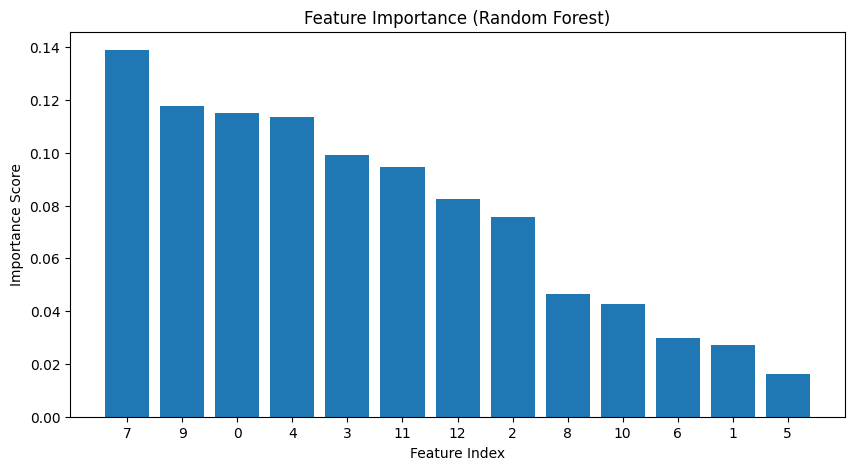

Feature ranking (Random Forest):
1. Feature 7 (0.1389)
2. Feature 9 (0.1179)
3. Feature 0 (0.1152)
4. Feature 4 (0.1136)
5. Feature 3 (0.0993)
6. Feature 11 (0.0948)
7. Feature 12 (0.0824)
8. Feature 2 (0.0757)
9. Feature 8 (0.0464)
10. Feature 10 (0.0426)
11. Feature 6 (0.0298)
12. Feature 1 (0.0271)
13. Feature 5 (0.0162)


In [22]:
plt.figure(figsize=(10,5))
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.title("Feature Importance (Random Forest)")
plt.show()

print("Feature ranking (Random Forest):")
for f in range(X.shape[1]):
    print(f"{f+1}. Feature {indices[f]} ({importances[indices[f]]:.4f})")

# 3. Scale your feature

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=2000, solver="lbfgs")  # more iterations
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_scaled, y)

print("Selected features (RFE):", X.columns[rfe.support_].tolist())

Selected features (RFE): [2, 6, 9, 11, 12]


# 4. Recursive Feature Elimination (RFE)


In [28]:
model = LogisticRegression(max_iter=2000, solver="liblinear")
rfe = RFE(model, n_features_to_select=5)  # choose top 5
rfe.fit(X, y)

print("Selected features (RFE):", X.columns[rfe.support_].tolist())

Selected features (RFE): [1, 5, 8, 9, 11]


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in

# 5. Chi-Square Test


In [29]:
X_scaled = MinMaxScaler().fit_transform(X)

chi2_selector = SelectKBest(chi2, k=5)
chi2_selector.fit(X_scaled, y)

chi2_features = X.columns[chi2_selector.get_support()].tolist()
print("Selected features (Chi-Square):", chi2_features)

Selected features (Chi-Square): [8, 9, 10, 11, 12]


# 6. Final Reduced Dataset


In [ ]:
selected_features = list(set(X.columns[rfe.support_]) | set(chi2_features))  
X_reduced = X[selected_features]

print("Final selected features:", selected_features)
print("Reduced dataset shape:", X_reduced.shape)

Final selected features: [1, 5, 8, 9, 10, 11, 12]
Reduced dataset shape: (297, 7)
